In [1]:
# Importamos librerías necesarias
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
pip install -U scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\anfre\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_csv(r"C:\Users\anfre\Downloads\spotifydataset.csv")

In [4]:
df

,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,Outkast,"atl hip hop, dirty south rap, hip hop, old sch...",2769972,69,https://open.spotify.com/artist/1G9G7WwrXka3Z1...,Roses,Speakerboxxx/The Love Below,2003,369573,...,0.708,0,-5.653,1,0.0545,0.0482,0.000018,0.1070,0.509,108.970
996,996,Outkast,"atl hip hop, dirty south rap, hip hop, old sch...",2769972,64,https://open.spotify.com/artist/1G9G7WwrXka3Z1...,Rosa Parks,Aquemini,1998-09-29,324373,...,0.701,6,-7.198,0,0.2830,0.1050,0.000000,0.7610,0.251,103.890
997,997,Outkast,"atl hip hop, dirty south rap, hip hop, old sch...",2769972,60,https://open.spotify.com/artist/1G9G7WwrXka3Z1...,B.O.B. - Bombs Over Baghdad,Stankonia,2000-10-31,304226,...,0.978,9,-5.324,1,0.0978,0.0555,0.000041,0.0260,0.653,153.809
998,998,Outkast,"atl hip hop, dirty south rap, hip hop, old sch...",2769972,59,https://open.spotify.com/artist/1G9G7WwrXka3Z1...,Da Art of Storytellin' (Pt. 1),Aquemini,1998-09-29,222653,...,0.856,2,-5.833,1,0.2350,0.1070,0.000000,0.7450,0.402,103.773


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_popularity  1000 non-null   int64  
 1   danceability      1000 non-null   float64
 2   energy            1000 non-null   float64
 3   key               1000 non-null   int64  
 4   loudness          1000 non-null   float64
 5   mode              1000 non-null   int64  
 6   speechiness       1000 non-null   float64
 7   acousticness      1000 non-null   float64
 8   instrumentalness  1000 non-null   float64
 9   liveness          1000 non-null   float64
 10  valence           1000 non-null   float64
 11  tempo             1000 non-null   float64
dtypes: float64(9), int64(3)
memory usage: 93.9 KB


In [8]:
columnas = [
    "track_popularity",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

# Eliminar todas las demás columnas
spotify = df[columnas]


In [9]:
spotify


,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,89,0.645,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,85,0.795,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,83,0.506,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,80,0.650,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,79,0.787,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998
...,...,...,...,...,...,...,...,...,...,...,...,...
995,69,0.751,0.708,0,-5.653,1,0.0545,0.0482,0.000018,0.1070,0.509,108.970
996,64,0.792,0.701,6,-7.198,0,0.2830,0.1050,0.000000,0.7610,0.251,103.890
997,60,0.746,0.978,9,-5.324,1,0.0978,0.0555,0.000041,0.0260,0.653,153.809
998,59,0.749,0.856,2,-5.833,1,0.2350,0.1070,0.000000,0.7450,0.402,103.773


In [43]:
from matplotlib.pyplot import axes


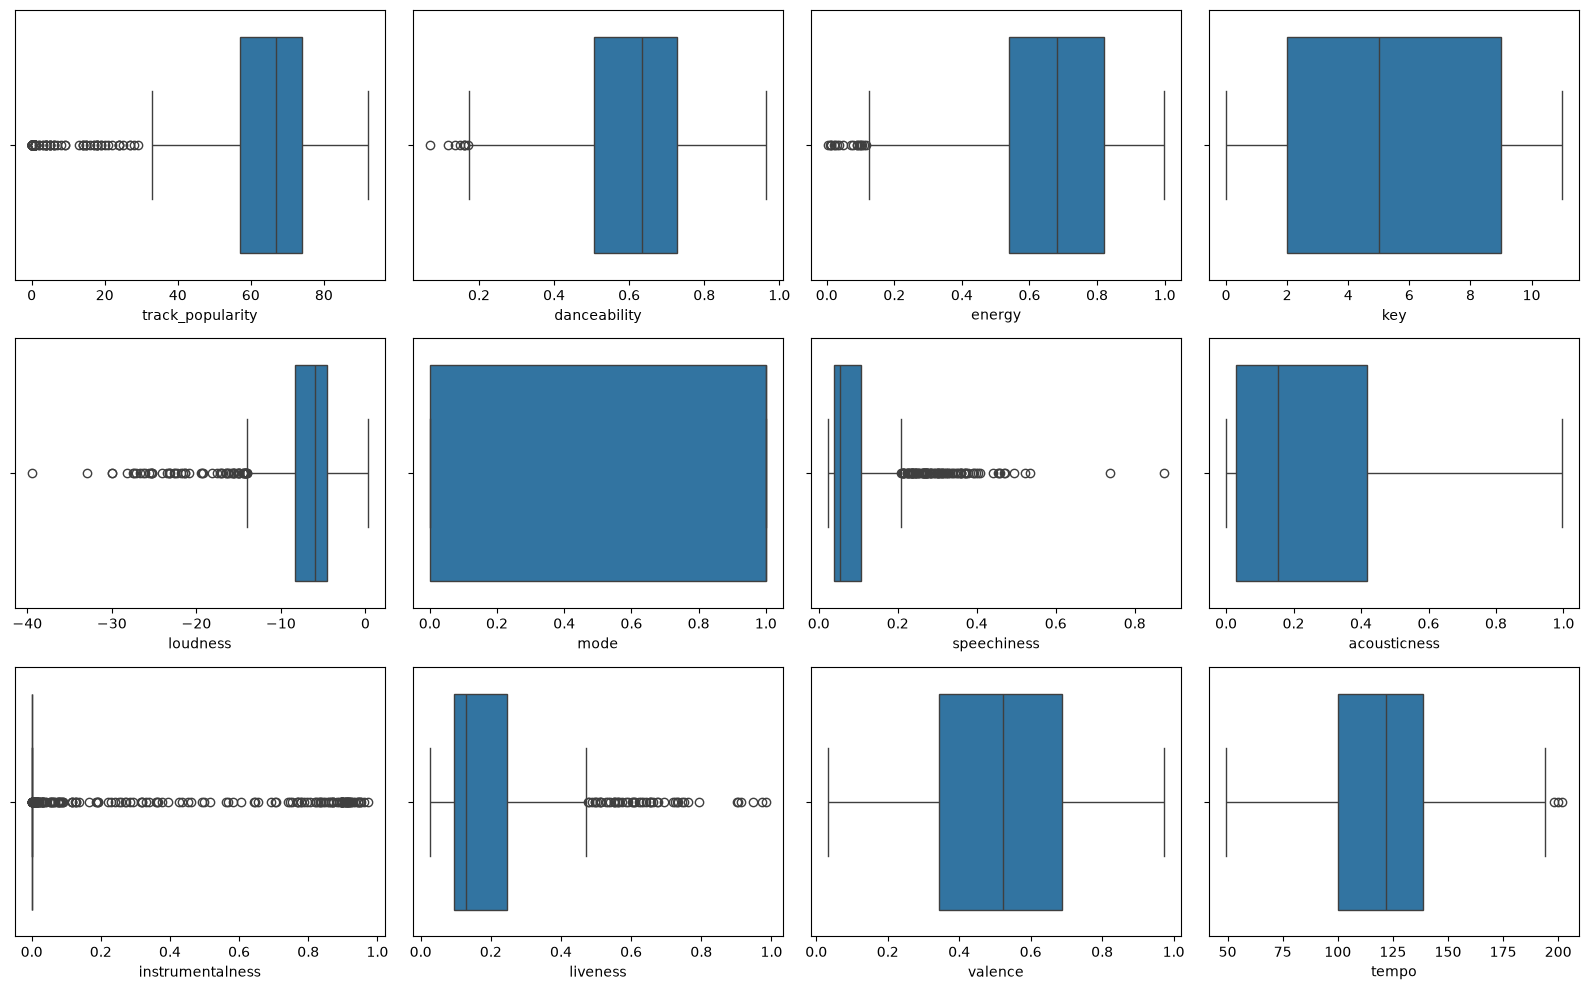

In [47]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

sns.boxplot(x=spotify['track_popularity'], ax=axes[0, 0])
sns.boxplot(x=spotify['danceability'], ax=axes[0, 1])
sns.boxplot(x=spotify['energy'], ax=axes[0, 2])
sns.boxplot(x=spotify['key'], ax=axes[0, 3])

sns.boxplot(x=spotify['loudness'], ax=axes[1, 0])
sns.boxplot(x=spotify['mode'], ax=axes[1, 1])
sns.boxplot(x=spotify['speechiness'], ax=axes[1, 2])
sns.boxplot(x=spotify['acousticness'], ax=axes[1, 3])

sns.boxplot(x=spotify['instrumentalness'], ax=axes[2, 0])
sns.boxplot(x=spotify['liveness'], ax=axes[2, 1])
sns.boxplot(x=spotify['valence'], ax=axes[2, 2])
sns.boxplot(x=spotify['tempo'], ax=axes[2, 3])

plt.tight_layout()
plt.show()

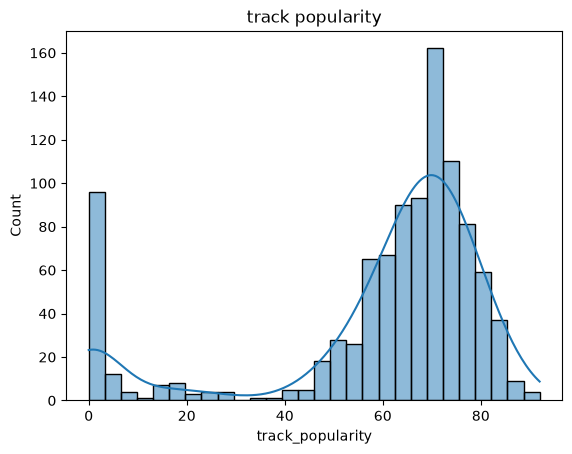

In [51]:
sns.histplot(data=spotify, x='track_popularity', kde=True)
plt.title('track popularity')
plt.show()

In [11]:
### REDUCCIÓN DE DIMENSIONALIDAD CON PCA

pca = PCA(2) # Conservamos el 96% de la varianza (puede ser un número o un porcentaje)
X_pca = pca.fit_transform(spotify)

In [18]:
spotify.shape

(1000, 12)

In [15]:
X_pca.shape

(1000, 2)

In [28]:
pca.explained_variance_ratio_


array([0.57337941, 0.40318995])

In [29]:
pca.components_


array([[-2.10053318e-01, -8.55367085e-04,  1.13236896e-03,
         1.79288033e-04,  9.49768182e-03,  3.86154673e-04,
         2.71311822e-04, -1.36290410e-03,  4.58218539e-04,
         3.32144216e-04, -1.69464177e-04,  9.77641510e-01],
       [ 9.76884402e-01,  7.19267228e-04,  1.15155738e-03,
         6.94270504e-03,  4.18453734e-02, -2.52384375e-04,
        -4.31640764e-04, -1.52259690e-03, -2.98461886e-03,
         1.01365879e-04,  1.28858410e-03,  2.09481832e-01]])

Text(0, 0.5, 'Componente principal 2')

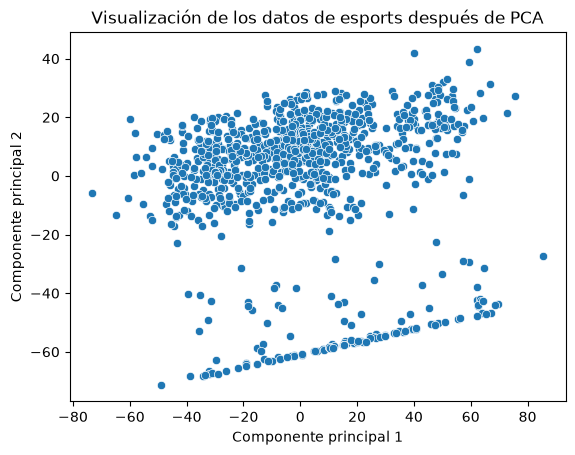

In [53]:
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1])
plt.title("Visualización de los datos de esports después de PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")

In [33]:
# DBScan
from sklearn.cluster import DBSCAN

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=0.25, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

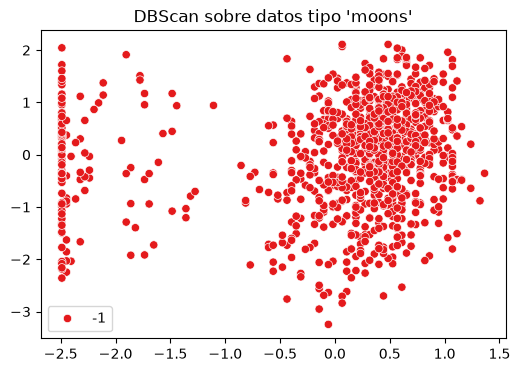

In [34]:
# Visualizar DBScan
plt.figure(figsize=(6, 4))
plt.title("DBScan sobre datos tipo 'moons'")
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels_dbscan, palette='Set1')
plt.show()


Text(0, 0.5, 'Componente principal 2')

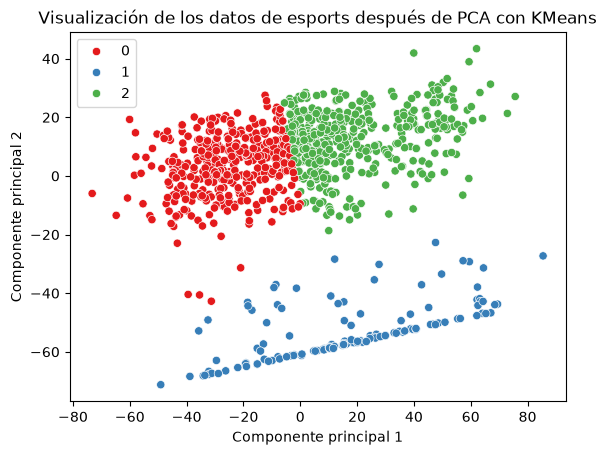

In [56]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(spotify)

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=kmeans.labels_,
    palette="Set1"
)
plt.title("Visualización de los datos de esports después de PCA con KMeans")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")

In [59]:
data_clusters = pd.concat(
    [X.reset_index(drop=True),
     pd.Series(kmeans.labels_, name="Cluster")],
    axis=1
)

data_scaled_clusters = pd.concat(
    [pd.DataFrame(X_scaled, columns=X.columns),
     pd.Series(kmeans.labels_, name="Cluster")],
    axis=1
)
data_scaled_clusters = pd.concat(
    [
        pd.DataFrame(X_scaled, columns=X.columns),
        pd.Series(kmeans.labels_, name="Cluster")
    ],
    axis=1
)


In [60]:
data_clusters.head()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Cluster
0,89,0.645,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842,0
1,85,0.795,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998,0
2,83,0.506,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726,0
3,80,0.650,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091,0
4,79,0.787,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998,0


In [61]:
data_scaled_clusters.head()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Cluster
0,1.238679,0.200823,-0.070192,-0.067277,-0.262122,0.794557,-0.538762,-0.707668,-0.331336,-0.789715,-0.952150,-0.224734,0
1,1.071126,1.098154,-0.147313,0.486445,0.291770,-1.258562,-0.531018,-0.376933,-0.331471,-0.795218,-0.299172,-0.861119,0
2,0.987349,-0.630704,-1.439104,1.317029,-0.518074,0.794557,-0.550930,1.399684,-0.331471,-0.088114,-0.565518,-1.334449,0
3,0.861684,0.230734,0.792609,-1.451583,0.561793,0.794557,-0.651599,-0.846195,-0.331363,-0.654898,0.328030,-0.144526,0
4,0.819796,1.050296,0.551603,-1.174722,0.122029,0.794557,-0.404905,-0.262648,-0.331181,-0.521456,1.161436,-0.112179,0


In [62]:
data_clusters.groupby('Cluster').agg(['mean', 'median'])

track_popularity        danceability            energy          \
                    mean median         mean  median      mean  median   
Cluster                                                                  
0              68.297872   69.0     0.631324  0.6570  0.640180  0.6580   
1               4.154412    0.0     0.590324  0.6025  0.626463  0.6295   
2              67.968254   69.0     0.598857  0.6160  0.690629  0.7110   

              key         loudness         ... acousticness         \
             mean median      mean median  ...         mean median   
Cluster                                    ...                       
0        5.340426    5.0 -7.128920 -6.083  ...     0.286772  0.194   
1        4.985294    5.0 -8.549816 -8.584  ...     0.313585  0.155   
2        5.229025    5.0 -6.762052 -5.515  ...     0.231038  0.123   

        instrumentalness            liveness           valence          \
                    mean    median      mean  median      mean  median   
Cluster                                                                  
0               0.055241  0.000002  0.174402  0.1200  0.523326  0.5320   
1               0.221581  0.000271  0.191263  0.1165  0.452781  0.4315   
2               0.048068  0.000003  0.201873  0.1450  0.529923  0.5250   

              tempo           
               mean   median  
Cluster                       
0         98.654390   98.043  
1        127.651169  126.508  
2        142.975243  136.904  

[3 rows x 24 columns]

<Axes: ylabel='Cluster'>

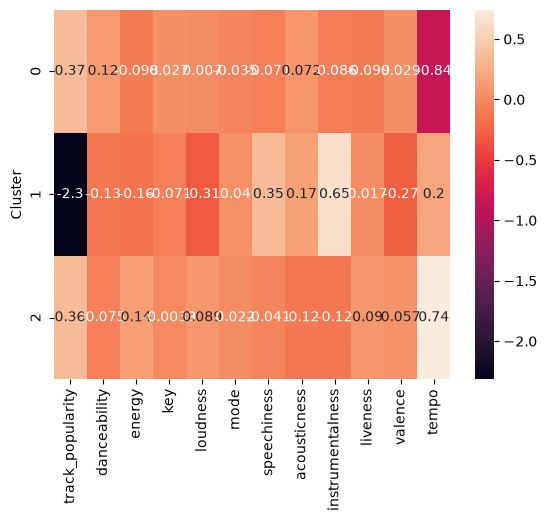

In [63]:
sns.heatmap(data_scaled_clusters.groupby('Cluster').mean(), annot=True)